#**TF-IDF dan Word Embeding**

## **TF-IDF**

In [1]:
!pip install scikit-learn

In [3]:
import pandas as pd
import ast
from sklearn.feature_extraction.text import TfidfVectorizer

In [4]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
# Baca CSV dari path Drive
df = pd.read_csv('/content/drive/MyDrive/Semester 7/PPW/hasil_preprocessing_berita.csv')
df.head()

,Teks Asli,Setelah Stopword Removal,Setelah Cleaning,Setelah Normalisasi,Setelah Stemming,Tokenisasi Akhir
0,alfamart kembali menggelar aksi donor darah se...,"['alfamart', 'kembali', 'menggelar', 'aksi', '...","['alfamart', 'kembali', 'menggelar', 'aksi', '...","['alfamart', 'kembali', 'menggelar', 'aksi', '...","['alfamart', 'kembali', 'gelar', 'aksi', 'dono...","['alfamart', 'kembali', 'gelar', 'aksi', 'dono..."
1,"menteri koordinator bidang hukum, ham, imigras...","['menteri', 'koordinator', 'bidang', 'hukum,',...","['menteri', 'koordinator', 'bidang', 'hukum', ...","['menteri', 'koordinator', 'bidang', 'hukum', ...","['menteri', 'koordinator', 'bidang', 'hukum', ...","['menteri', 'koordinator', 'bidang', 'hukum', ..."
2,gubernur sumatera utara (sumut) bobby nasution...,"['gubernur', 'sumatera', 'utara', '(sumut)', '...","['gubernur', 'sumatera', 'utara', 'sumut', 'bo...","['gubernur', 'sumatera', 'utara', 'sumut', 'bo...","['gubernur', 'sumatera', 'utara', 'sumut', 'bo...","['gubernur', 'sumatera', 'utara', 'sumut', 'bo..."
3,dukungan untuk plt ketua umum partai persatuan...,"['dukungan', 'plt', 'ketua', 'umum', 'partai',...","['dukungan', 'plt', 'ketua', 'umum', 'partai',...","['dukungan', 'plt', 'ketua', 'umum', 'partai',...","['dukung', 'plt', 'ketua', 'umum', 'partai', '...","['dukung', 'plt', 'ketua', 'umum', 'partai', '..."
4,bagi pengguna whoosh rute jakarta-bandung atau...,"['bagi', 'pengguna', 'whoosh', 'rute', 'jakart...","['bagi', 'pengguna', 'whoosh', 'rute', 'jakart...","['bagi', 'pengguna', 'whoosh', 'rute', 'jakart...","['bagi', 'guna', 'whoosh', 'rute', 'jakartaban...","['bagi', 'guna', 'whoosh', 'rute', 'jakartaban..."


In [9]:
print(type(df["Tokenisasi Akhir"].iloc[0]))
print(df["Tokenisasi Akhir"].iloc[0])

<class 'str'>
['alfamart', 'kembali', 'gelar', 'aksi', 'donor', 'darah', 'serentak', 'kotakabupaten', 'lama', 'satu', 'minggu', 'september', 'dalam', 'program', 'sehat', 'tetes', 'darah', 'pertiwi', 'giat', 'sosial', 'ini', 'alfamart', 'target', 'kumpul', 'kantong', 'darah', 'bantu', 'penuh', 'stok', 'palang', 'merah', 'indonesia', 'pmi', 'ini', 'salah', 'satu', 'kontribusi', 'alfamart', 'bantu', 'pasien', 'butuh', 'transfusi', 'darah', 'gandeng', 'pmi', 'daerah', 'harap', 'ribu', 'kantong', 'darah', 'dapat', 'capai', 'salur', 'kepada', 'butuh', 'kata', 'corporate', 'affairs', 'director', 'alfamart', 'solihin', 'dalam', 'terang', 'tulis', 'rabu', 'scroll', 'continue', 'with', 'content', 'giat', 'donor', 'darah', 'kali', 'jadi', 'bagi', 'rangkai', 'semarak', 'ulang', 'tahun', 'alfamart', 'sua', 'ke', 'target', 'kantong', 'darah', 'pilih', 'bagai', 'refleksi', 'usia', 'alfamart', 'telah', 'tahun', 'layan', 'masyarakat', 'indonesia', 'solihin', 'tambah', 'donor', 'darah', 'telah', 'jadi',

In [10]:
df["Tokenisasi Akhir_joined"] = df["Tokenisasi Akhir"].apply(
    lambda x: " ".join(ast.literal_eval(x)) if isinstance(x, str) else ""
)


df[["Tokenisasi Akhir", "Tokenisasi Akhir_joined"]].head()

,Tokenisasi Akhir,Tokenisasi Akhir_joined
0,"['alfamart', 'kembali', 'gelar', 'aksi', 'dono...",alfamart kembali gelar aksi donor darah serent...
1,"['menteri', 'koordinator', 'bidang', 'hukum', ...",menteri koordinator bidang hukum ham imigrasi ...
2,"['gubernur', 'sumatera', 'utara', 'sumut', 'bo...",gubernur sumatera utara sumut bobby nasution t...
3,"['dukung', 'plt', 'ketua', 'umum', 'partai', '...",dukung plt ketua umum partai satu bangun ppp m...
4,"['bagi', 'guna', 'whoosh', 'rute', 'jakartaban...",bagi guna whoosh rute jakartabandung atau bali...


In [11]:
vectorizer = TfidfVectorizer(max_features=1000)  # ambil 1000 fitur teratas

X_tfidf = vectorizer.fit_transform(df["Tokenisasi Akhir_joined"])

tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=vectorizer.get_feature_names_out()
)

tfidf_df.head()

,acara,ada,adapun,adil,afp,afriansyah,agam,agama,agar,agenda,...,wira,with,wujud,xiii,ya,yaitu,yakin,yakni,yang,yayasan
0,0.016249,0.010689,0.0,0.0,0.0,0.0,0.0,0.0,0.013411,0.0,...,0.0,0.005929,0.018111,0.0,0.0,0.000000,0.00000,0.0,0.000000,0.0
1,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.012363,0.000000,0.0,0.0,0.000000,0.00000,0.0,0.035928,0.0
2,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.014949,0.000000,0.0,0.0,0.000000,0.00000,0.0,0.000000,0.0
3,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.033599,0.0,...,0.0,0.014854,0.000000,0.0,0.0,0.000000,0.04709,0.0,0.000000,0.0
4,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.029843,0.000000,0.0,0.0,0.079639,0.00000,0.0,0.000000,0.0


## **Word Embeding**

In [14]:
!pip install gensim

In [16]:
!pip install --upgrade --force-reinstall numpy gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.4 MB/s eta 0:00:00
  Using cached gensim-4.3.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.1 kB)
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scipy-1.13.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached gensim-4.3.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (26.6 MB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
Using cached scipy-1.13.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (38.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 6.5 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.3
    Uninstalling wrapt-1.17.3:
      Successfully uninstalled wrapt-1.17.3
  Attempting un

In [1]:
import pandas as pd
import ast
from gensim.models import Word2Vec

In [2]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Baca CSV dari path Drive
df = pd.read_csv('/content/drive/MyDrive/Semester 7/PPW/hasil_preprocessing_berita.csv')
df.head()

,Teks Asli,Setelah Stopword Removal,Setelah Cleaning,Setelah Normalisasi,Setelah Stemming,Tokenisasi Akhir
0,alfamart kembali menggelar aksi donor darah se...,"['alfamart', 'kembali', 'menggelar', 'aksi', '...","['alfamart', 'kembali', 'menggelar', 'aksi', '...","['alfamart', 'kembali', 'menggelar', 'aksi', '...","['alfamart', 'kembali', 'gelar', 'aksi', 'dono...","['alfamart', 'kembali', 'gelar', 'aksi', 'dono..."
1,"menteri koordinator bidang hukum, ham, imigras...","['menteri', 'koordinator', 'bidang', 'hukum,',...","['menteri', 'koordinator', 'bidang', 'hukum', ...","['menteri', 'koordinator', 'bidang', 'hukum', ...","['menteri', 'koordinator', 'bidang', 'hukum', ...","['menteri', 'koordinator', 'bidang', 'hukum', ..."
2,gubernur sumatera utara (sumut) bobby nasution...,"['gubernur', 'sumatera', 'utara', '(sumut)', '...","['gubernur', 'sumatera', 'utara', 'sumut', 'bo...","['gubernur', 'sumatera', 'utara', 'sumut', 'bo...","['gubernur', 'sumatera', 'utara', 'sumut', 'bo...","['gubernur', 'sumatera', 'utara', 'sumut', 'bo..."
3,dukungan untuk plt ketua umum partai persatuan...,"['dukungan', 'plt', 'ketua', 'umum', 'partai',...","['dukungan', 'plt', 'ketua', 'umum', 'partai',...","['dukungan', 'plt', 'ketua', 'umum', 'partai',...","['dukung', 'plt', 'ketua', 'umum', 'partai', '...","['dukung', 'plt', 'ketua', 'umum', 'partai', '..."
4,bagi pengguna whoosh rute jakarta-bandung atau...,"['bagi', 'pengguna', 'whoosh', 'rute', 'jakart...","['bagi', 'pengguna', 'whoosh', 'rute', 'jakart...","['bagi', 'pengguna', 'whoosh', 'rute', 'jakart...","['bagi', 'guna', 'whoosh', 'rute', 'jakartaban...","['bagi', 'guna', 'whoosh', 'rute', 'jakartaban..."


In [8]:
corpus = df["Tokenisasi Akhir"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
).tolist()

In [9]:
model = Word2Vec(
    sentences=corpus,
    vector_size=100,   # dimensi vektor
    window=5,          # konteks window
    min_count=2,       # kata muncul minimal 2 kali
    sg=1,              # 1=skip-gram, 0=CBOW
    workers=4
)

In [10]:
model.save("word2vec_berita.model")

In [11]:
# === Cek hasil ===
print("\nVektor untuk kata 'indonesia':")
print(model.wv['indonesia'][:10])

print("\nKata yang mirip dengan 'indonesia':")
print(model.wv.most_similar("indonesia", topn=5))


Vektor untuk kata 'indonesia':
[-0.10769716  0.16461094 -0.01713117 -0.11248162  0.06770208 -0.34250796
  0.07890345  0.31476623 -0.1776477  -0.01983514]

Kata yang mirip dengan 'indonesia':
[('selamat', 0.9722529649734497), ('republik', 0.9701743125915527), ('atur', 0.9699234366416931), ('segala', 0.9698802828788757), ('prioritas', 0.966983437538147)]


## **Klasifikasi TF-IDF & WordEmbeding 2Vec**

In [12]:
import pandas as pd
import ast
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [13]:
from gensim.models import Word2Vec
import numpy as np

In [14]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# Baca CSV dari path Drive
df = pd.read_csv('/content/drive/MyDrive/Semester 7/PPW/hasil_preprocessing_berita.csv')
df.head()

,Teks Asli,Setelah Stopword Removal,Setelah Cleaning,Setelah Normalisasi,Setelah Stemming,Tokenisasi Akhir
0,alfamart kembali menggelar aksi donor darah se...,"['alfamart', 'kembali', 'menggelar', 'aksi', '...","['alfamart', 'kembali', 'menggelar', 'aksi', '...","['alfamart', 'kembali', 'menggelar', 'aksi', '...","['alfamart', 'kembali', 'gelar', 'aksi', 'dono...","['alfamart', 'kembali', 'gelar', 'aksi', 'dono..."
1,"menteri koordinator bidang hukum, ham, imigras...","['menteri', 'koordinator', 'bidang', 'hukum,',...","['menteri', 'koordinator', 'bidang', 'hukum', ...","['menteri', 'koordinator', 'bidang', 'hukum', ...","['menteri', 'koordinator', 'bidang', 'hukum', ...","['menteri', 'koordinator', 'bidang', 'hukum', ..."
2,gubernur sumatera utara (sumut) bobby nasution...,"['gubernur', 'sumatera', 'utara', '(sumut)', '...","['gubernur', 'sumatera', 'utara', 'sumut', 'bo...","['gubernur', 'sumatera', 'utara', 'sumut', 'bo...","['gubernur', 'sumatera', 'utara', 'sumut', 'bo...","['gubernur', 'sumatera', 'utara', 'sumut', 'bo..."
3,dukungan untuk plt ketua umum partai persatuan...,"['dukungan', 'plt', 'ketua', 'umum', 'partai',...","['dukungan', 'plt', 'ketua', 'umum', 'partai',...","['dukungan', 'plt', 'ketua', 'umum', 'partai',...","['dukung', 'plt', 'ketua', 'umum', 'partai', '...","['dukung', 'plt', 'ketua', 'umum', 'partai', '..."
4,bagi pengguna whoosh rute jakarta-bandung atau...,"['bagi', 'pengguna', 'whoosh', 'rute', 'jakart...","['bagi', 'pengguna', 'whoosh', 'rute', 'jakart...","['bagi', 'pengguna', 'whoosh', 'rute', 'jakart...","['bagi', 'guna', 'whoosh', 'rute', 'jakartaban...","['bagi', 'guna', 'whoosh', 'rute', 'jakartaban..."


In [16]:
# Gabungkan token untuk TF-IDF
df["Tokenisasi Akhir_joined"] = df["Tokenisasi Akhir"].apply(
    lambda x: " ".join(ast.literal_eval(x)) if isinstance(x, str) else ""
)

# Buat list of tokens untuk Word2Vec
corpus = df["Tokenisasi Akhir"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
).tolist()

In [18]:
X_text = df["Tokenisasi Akhir_joined"]
y = df["Teks Asli"]

# === Split data (train/test) ===
X_train, X_test, y_train, y_test, corpus_train, corpus_test = train_test_split(
    X_text, y, corpus, test_size=0.2, random_state=42
)

In [20]:
print(X_train.isna().sum())
print(y_train.isna().sum())


0
13


In [22]:
X_train = X_train.fillna("Teks Asli")
X_test = X_test.fillna("Teks Asli")


In [37]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Naive Bayes (cocok untuk teks)
model_tfidf = MultinomialNB()
model_tfidf.fit(X_train_tfidf, y_train)

# Prediksi
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

print("=== Hasil TF-IDF + Naive Bayes ===")
print("Akurasi:", accuracy_score(y_test, y_pred_tfidf))
print(classification_report(y_test, y_pred_tfidf))

=== Hasil TF-IDF + Naive Bayes ===
Akurasi: 0.0
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


=== Hasil Word2Vec + Logistic Regression ===
Akurasi: 0.0
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

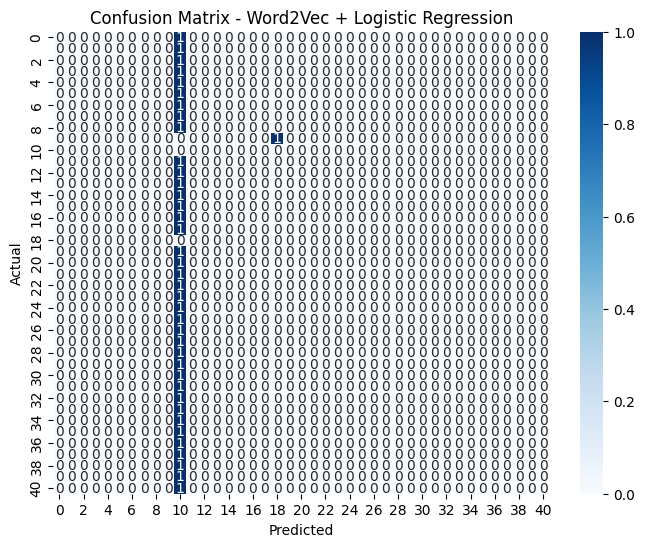

In [39]:
import pandas as pd
import numpy as np
import re
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk

# ================================
# 1. Download stopwords NLTK
# ================================
nltk.download('stopwords')
stop_words = set(stopwords.words('indonesian'))

# ================================
# 2. Tangani NaN & preprocessing teks
# ================================
def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = ' '.join([w for w in text.split() if w not in stop_words])
    return text

X_train_clean = X_train.fillna("").apply(clean_text)
X_test_clean = X_test.fillna("").apply(clean_text)

# ================================
# 3. Pastikan label konsisten
# ================================
y_train_clean = y_train.dropna().astype(str).str.strip()
y_test_clean = y_test.dropna().astype(str).str.strip()

# Sesuaikan X_train/X_test jika ada baris dihapus dari y_train/y_test
X_train_clean = X_train_clean.iloc[:len(y_train_clean)]
X_test_clean = X_test_clean.iloc[:len(y_test_clean)]

# ================================
# 4. Tokenisasi untuk Word2Vec
# ================================
X_train_tokens = [text.split() for text in X_train_clean]
X_test_tokens = [text.split() for text in X_test_clean]

# ================================
# 5. Train Word2Vec
# ================================
w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1,
    seed=42
)

# ================================
# 6. Buat fitur rata-rata Word2Vec per dokumen
# ================================
def document_vector(tokens, model):
    # ambil vektor untuk kata yang ada di vocabulary
    vecs = [model.wv[word] for word in tokens if word in model.wv]
    if len(vecs) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)

X_train_w2v = np.array([document_vector(doc, w2v_model) for doc in X_train_tokens])
X_test_w2v = np.array([document_vector(doc, w2v_model) for doc in X_test_tokens])

# ================================
# 7. Pastikan jumlah sampel konsisten
# ================================
X_train_w2v = X_train_w2v[:len(y_train_clean)]
X_test_w2v = X_test_w2v[:len(y_test_clean)]

# ================================
# 8. Logistic Regression
# ================================
model_w2v = LogisticRegression(max_iter=1000)
model_w2v.fit(X_train_w2v, y_train_clean)

# ================================
# 9. Prediksi
# ================================
y_pred_w2v = model_w2v.predict(X_test_w2v)

# ================================
# 10. Evaluasi
# ================================
print("=== Hasil Word2Vec + Logistic Regression ===")
print("Akurasi:", accuracy_score(y_test_clean, y_pred_w2v))
print(classification_report(y_test_clean, y_pred_w2v))

# ================================
# 11. Confusion Matrix
# ================================
cm = confusion_matrix(y_test_clean, y_pred_w2v)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Word2Vec + Logistic Regression')
plt.show()


In [40]:
acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
acc_w2v = accuracy_score(y_test, y_pred_w2v)

print("\n=== Perbandingan Akurasi ===")
print(f"TF-IDF + Naive Bayes        : {acc_tfidf:.4f}")
print(f"Word2Vec + LogisticReg      : {acc_w2v:.4f}")


=== Perbandingan Akurasi ===
TF-IDF + Naive Bayes        : 0.0000
Word2Vec + LogisticReg      : 0.0000


In [41]:
!pip install seaborn

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# === Fungsi untuk plot confusion matrix ===
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=sorted(set(y_true)))
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=sorted(set(y_true)),
                yticklabels=sorted(set(y_true)))
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:
plot_confusion(y_test, y_pred_tfidf, "Confusion Matrix - TF-IDF + Naive Bayes")
plot_confusion(y_test, y_pred_w2v, "Confusion Matrix - Word2Vec + Logistic Regression")